# 2D per-subject decoder embedding

Fits `HierarchicalDecoderCumulativeLink` (the AL-RNN's own ordinal observation model, from `hierarchical_decoder.py`) with `decoder_mode='hierarchical'` and `feature_dim=2`, using the raw 9-dim cue one-hot as the (static, non-recurrent) input `z_t` -- i.e. no RNN at all, see `decoder_only_ablation.py`.

The fit learns a 2-number embedding per subject; a shared linear projection then expands each subject's 2 numbers into that subject's full decoder parameters (`beta_0`, `beta`). Since `feature_dim=2` already gets test MAE close to the `feature_dim=16` / fully-individual ceiling (~0.70 vs ~0.67-0.69), these 2 numbers capture most of what distinguishes one subject's decoding from another's here -- and being 2D, we can just look at them directly.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve().parents[1]  # comparisons/baseline_models -> repo root
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "comparisons" / "baseline_models"))

from hierarchical_decoder import HierarchicalDecoderCumulativeLink
from decoder_only_ablation import build_features, DEFAULT_INPUTS, DEFAULT_INVESTS
from data import load_dataset

In [2]:
subjects, n_train_trials, n_test_trials = load_dataset(str(DEFAULT_INPUTS), str(DEFAULT_INVESTS))
invests_np = np.load(DEFAULT_INVESTS)          # (n_subj, 160, 1), NaN at feedback/omission steps
n_subj, total_T, _ = invests_np.shape
n_train_timesteps = int(total_T * 0.75)

z_np = build_features(subjects, "raw_cue")      # (n_subj, 160, 9): full identity+expression one-hot
dz = z_np.shape[-1]
print(f"n_subjects={n_subj}  dz={dz}  n_train_timesteps={n_train_timesteps}  total_T={total_T}")

n_subjects=32  dz=9  n_train_timesteps=120  total_T=160


In [10]:
FEATURE_DIM = 16
N_EPOCHS = 600
LR = 0.03
SEED = 0

torch.manual_seed(SEED)
decoder = HierarchicalDecoderCumulativeLink(
    dz=dz, dq=1, num_categories=5, n_subjects=n_subj,
    decoder_mode="hierarchical", feature_dim=FEATURE_DIM,
)
# The learned 2D embedding itself: one row per subject, optimised jointly with the decoder's
# shared projection weights.
subject_features = torch.nn.Parameter(torch.randn(n_subj, FEATURE_DIM) * 0.1)

z = torch.tensor(z_np, dtype=torch.float32)
x = torch.tensor(invests_np, dtype=torch.float32)
z_train, x_train = z[:, :n_train_timesteps], x[:, :n_train_timesteps]

optimizer = torch.optim.Adam(list(decoder.parameters()) + [subject_features], lr=LR)
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    loss = -decoder.log_likelihood(x_train, z_train, feature_vectors=subject_features)
    loss.backward()
    optimizer.step()
    if epoch % 200 == 0 or epoch == N_EPOCHS - 1:
        print(f"epoch {epoch:4d}  train_nll_sum={loss.item():.2f}")

epoch    0  train_nll_sum=3809.35
epoch  200  train_nll_sum=2100.44
epoch  400  train_nll_sum=2100.36
epoch  599  train_nll_sum=2100.34


In [11]:
# Sanity check: reproduce the test MAE from the sweep (should land close to ~0.70).
with torch.no_grad():
    log_probs, valid_mask = decoder.log_likelihood_per_timestep(x, z, feature_vectors=subject_features)
    probs = decoder.get_category_probabilities(z, feature_vectors=subject_features)
    mode_action = torch.argmax(probs, dim=-1).squeeze(-1) + 1

x_np = x.squeeze(-1).numpy()
mode_np = mode_action.numpy().astype(float)
valid_np = valid_mask.numpy()
test_valid = valid_np.copy(); test_valid[:, :n_train_timesteps] = False
test_mae = np.mean(np.abs(mode_np[test_valid] - x_np[test_valid]))
print(f"test MAE (feature_dim={FEATURE_DIM}): {test_mae:.4f}")

test MAE (feature_dim=16): 0.6725


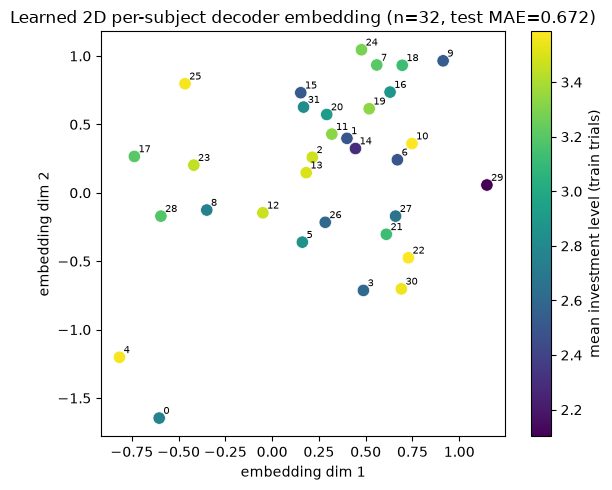

In [12]:
embedding = subject_features.detach().numpy()   # (n_subj, 2)

# Per-subject mean investment level (train trials only), just as an interpretable colour axis --
# not something the fit was told about.
mean_invest = np.array([
    np.nanmean(invests_np[s, :n_train_timesteps, 0]) for s in range(n_subj)
])

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(embedding[:, 0], embedding[:, 1], c=mean_invest, cmap="viridis", s=80, edgecolor="white", linewidth=0.5)
for i in range(n_subj):
    ax.annotate(str(i), (embedding[i, 0], embedding[i, 1]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("mean investment level (train trials)")
ax.set_xlabel("embedding dim 1")
ax.set_ylabel("embedding dim 2")
ax.set_title(f"Learned 2D per-subject decoder embedding (n={n_subj}, test MAE={test_mae:.3f})")
fig.tight_layout()
plt.show()

In [6]:
# Combine and sort
subjects_social = [103,112,113,114,115,120,121,122,123,125,126,140,147,148,149,150]
subjects_non_social = [128,130,131,133,134,135,136,137,138,139,141,142,143,144,145,146]

all_subjects = sorted(subjects_social + subjects_non_social)

# Create label vector aligned to sorted subjects
y = np.array([0 if s in subjects_social else 1 for s in all_subjects])

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Your feature matrix
X = embedding  # shape (32, 2)
# Optionally scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit logistic regression
clf = LogisticRegression()  # no regularization to test pure linearity, penalty='none'
clf.fit(X_scaled, y)

# Accuracy
acc = clf.score(X_scaled, y)
print(f"Training accuracy: {acc:.2f}")

# Cross-validation score (leave-one-out or 4-fold for robustness)
cv_score = cross_val_score(clf, X_scaled, y, cv=4).mean()
print(f"CV accuracy (4-fold): {cv_score:.2f}")

Training accuracy: 0.72
CV accuracy (4-fold): 0.75


Notes:
- The embedding is unsupervised with respect to `mean_invest` -- it was fit purely to predict choices, the colouring is added afterwards just to see if an obvious axis (e.g. "how much this subject invests overall") lines up with the embedding geometry.
- Rerunning with a different `SEED` will rotate/reflect the 2D embedding arbitrarily (the projection layer has no preferred orientation) -- absolute coordinates aren't meaningful, only the relative layout of subjects to each other and any correlation with `mean_invest` or other known covariates.
- Swap `"raw_cue"` for `"id+lin"` or `"fair+lin"` in the `build_features` call above to see the same embedding for a smaller `dz`.